# Klasifikasi Tutupan Lahan Sawah Menggunakan Citra Satelit Sentinel-2A dan Algoritma Random Forest — Kecamatan Bangkalan

Notebook ini mendokumentasikan klasifikasi tutupan lahan (*Land Use / Land Cover*) menjadi dua kelas (**Sawah** dan **Bukan Sawah**) menggunakan citra **Sentinel-2A (GeoTIFF)** dan algoritma *Random Forest*. Alur analisis mengikuti contoh notebook Kecamatan Sambeng, sementara batas wilayah, data, dan nama keluarannya disesuaikan untuk Kecamatan Bangkalan.

## Komponen Utama
1. **Batas wilayah kajian:** AOI Kecamatan Bangkalan dari GeoJSON atau berkas vektor yang tersedia.
2. **Petak sampel:** 50 petak sawah dan 50 petak bukan sawah. Sampel dapat dimuat dari berkas vektor atau dibuat dari koordinat yang sudah diverifikasi.
3. **Ekspor untuk QGIS:** Sampel disimpan sebagai GeoJSON dan Shapefile ZIP dengan gaya `.qml`.
4. **Citra Sentinel-2A:** Enam band (B2, B3, B4, B8, B11, B12), indeks spektral, serta pemeriksaan kualitas band.
5. **Ekstraksi fitur:** Piksel valid di dalam tiap petak sampel digunakan sebagai data latih.
6. **Random Forest:** Pembagian latih/uji dilakukan per petak, dilengkapi validasi silang per petak.
7. **Peta klasifikasi:** Hasil disimpan sebagai GeoTIFF, dihitung estimasi luasnya, dan dibandingkan dengan komposit citra.
8. **Peta interaktif:** Petak sampel dan batas kecamatan ditampilkan bersama basemap Google Satellite, Esri, dan OpenStreetMap.

**Berkas input (letakkan di folder kerja notebook):**

| Berkas | Keterangan |
|---|---|
| `Kecamatan_Bangkalan-KECAMATAN.geojson` atau `aoi_bangkalan.geojson` | Batas Kecamatan Bangkalan |
| `sentinel2_bangkalan.tif` | GeoTIFF minimal 6 band: B2, B3, B4, B8, B11, B12 |
| `sampel_sawah_bangkalan.zip` atau `.geojson` | Satu berkas sampel dengan kolom kelas (`class`, `kelas`, atau `label`) |
| `Sawah.zip` dan `Non sawah.zip` | Alternatif dua berkas terpisah; kelas diberikan otomatis |
| Daftar `sawah_coords` dan `nonsawah_coords` | Alternatif; gunakan koordinat yang sudah dicek pada citra satelit/QGIS |

## Alur Analisis
1. Memuat batas wilayah kajian (AOI).
2. Memuat atau membentuk petak sampel sawah dan bukan sawah.
3. Mengekspor sampel ke GeoJSON dan Shapefile ZIP untuk QGIS.
4. Memuat citra Sentinel-2A dan memeriksa kualitas band.
5. Mengekstrak nilai spektral dari petak sampel.
6. Melatih dan mengevaluasi model Random Forest.
7. Mengklasifikasikan seluruh piksel valid di dalam kecamatan.
8. Menampilkan petak pada peta interaktif.
9. Menyimpan keluaran dan meninjau hasil di QGIS.

In [8]:
import subprocess, sys
for mod, pkg in [("rasterio","rasterio"),("geopandas","geopandas"),("folium","folium"),("sklearn","scikit-learn")]:
    try: __import__(mod)
    except ImportError: subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, shutil, zipfile, warnings
from pathlib import Path
import numpy as np, pandas as pd, geopandas as gpd, rasterio
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from rasterio import features
from shapely.geometry import Point, box
warnings.filterwarnings("ignore", category=UserWarning)

# ---------------- PENGATURAN ----------------
BASE        = Path("/content") if "google.colab" in sys.modules else Path.cwd()
AOI_PATH    = BASE / "Kecamatan_Bangkalan-KECAMATAN.geojson"
TIF_PATH    = BASE / "sentinel2_bangkalan.tif"
SAMPLE_FILES = [BASE / "sampel_sawah_bangkalan.zip", BASE / "sampel_sawah_bangkalan.geojson"]
PATCH_M     = 50      # sisi petak sampel (m)
TEST_SIZE   = 0.20    # 80% latih / 20% uji (per petak)
N_TREES     = 100
SEED        = 42
PAKSA_TIFFFILE = False       # True = lewati rasterio, baca TIF dengan tifffile
PAKAI_BAND_TAMPAK = None   # None = otomatis (cek kualitas B2,B3,B4); True/False = paksa
OUT = BASE / "hasil_bangkalan"; OUT.mkdir(exist_ok=True)

---
## Langkah 1: Pemuatan Batas Wilayah Kajian (AOI Kecamatan Bangkalan)

Notebook mencari batas kecamatan dari `Kecamatan_Bangkalan-KECAMATAN.geojson` terlebih dahulu, lalu mencoba berkas GeoJSON/vektor lain yang namanya menunjukkan AOI atau batas Bangkalan. Batas ini dipakai untuk memotong area citra dan menghitung piksel yang dianalisis.

Berkas AOI: Kecamatan Bangkalan-KECAMATAN.geojson
Kolom atribut : ['kode_kec', 'kode_kk', 'kode_prov', 'kecamatan', 'kab_kota', 'provinsi', 'fid', 'nama', 'label']
Sistem Koordinat (CRS): EPSG:4326
Bujur : 112.6761 s/d 112.8079
Lintang: -7.0683 s/d -6.9786


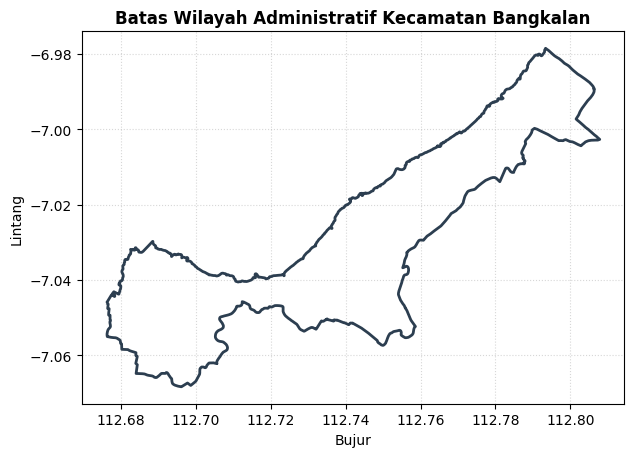

In [9]:
def cari_aoi():
    # pakai AOI_PATH bila ada; kalau tidak, cari berkas batas kecamatan di folder kerja
    if AOI_PATH.exists(): return AOI_PATH
    kunci, tolak = ("kecamatan", "aoi", "batas", "bangkalan"), ("sawah", "sampel", "klasifikasi", "kandidat")
    cands = [p for p in sorted(BASE.iterdir())
             if p.is_file() and p.suffix.lower() in (".geojson", ".json", ".shp", ".gpkg", ".zip")
             and any(k in p.stem.lower() for k in kunci) and not any(k in p.stem.lower().replace(" ", "") for k in tolak)]
    if not cands:
        raise FileNotFoundError("Berkas batas kecamatan tidak ditemukan di " + str(BASE) + ". Isi folder: "
                                + str(sorted(p.name for p in BASE.iterdir())) + ". Unggah berkasnya atau ubah AOI_PATH di sel pengaturan.")
    if len(cands) > 1: print("Beberapa kandidat AOI, dipakai yang pertama:", [p.name for p in cands])
    return cands[0]

aoi_file = cari_aoi()
print("Berkas AOI:", aoi_file.name)
gdf_aoi = (gpd.read_file(f"zip://{aoi_file}") if aoi_file.suffix == ".zip" else gpd.read_file(aoi_file)).to_crs(4326)
try:    aoi_geom = gdf_aoi.geometry.union_all()
except AttributeError: aoi_geom = gdf_aoi.geometry.unary_union

print("Kolom atribut :", [c for c in gdf_aoi.columns if c != "geometry"])
print("Sistem Koordinat (CRS):", gdf_aoi.crs)
minx, miny, maxx, maxy = gdf_aoi.total_bounds
print(f"Bujur : {minx:.4f} s/d {maxx:.4f}\nLintang: {miny:.4f} s/d {maxy:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
gdf_aoi.boundary.plot(ax=ax, color="#2c3e50", linewidth=2)
ax.set_title("Batas Wilayah Administratif Kecamatan Bangkalan", fontweight="bold")
ax.set_xlabel("Bujur"); ax.set_ylabel("Lintang"); ax.grid(True, ls=":", alpha=.5)
plt.show()

---
## Langkah 2: Petak Sampel (50 Sawah & 50 Non-Sawah)

Gunakan 50 petak sawah (kelas 1) dan 50 petak bukan sawah (kelas 0), seperti pada contoh Sambeng. Sampel dibaca dari `sampel_sawah_bangkalan.zip`/`.geojson` (kolom `class`, `kelas`, atau `label`), dari pasangan berkas `Sawah.zip` + `Non sawah.zip`, atau dari daftar koordinat `sawah_coords` dan `nonsawah_coords` di bawah (format `(lat, lon, 'keterangan')`).

Titik koordinat dibentuk menjadi petak persegi 50 m × 50 m **dalam meter (UTM 49S)**, lalu dikembalikan ke EPSG:4326. Koordinat contoh Kecamatan Sambeng tidak boleh dipakai untuk wilayah Bangkalan.

> **Penting:** koordinat/poligon harus diverifikasi visual di atas Google Satellite/QGIS. Sampel bukan sawah sebaiknya mencakup pemukiman, air/tambak, serta **tegalan, kebun, dan lahan bera** yang sering tertukar dengan sawah di Madura.

In [19]:
# ====== ISI DI SINI bila tidak memakai berkas sampel ======
sawah_coords = [
    # (-7.0xxxx, 112.7xxxx, 'Petak Sawah #01'),
]
nonsawah_coords = [
    # (-7.0xxxx, 112.7xxxx, 'Pemukiman'),
    # (-7.0xxxx, 112.7xxxx, 'Tegalan/Kebun'),
]
# ==========================================================

def to_class(v):
    s = str(v).strip().lower()
    if s in ("1", "1.0", "sawah"): return 1
    if s in ("0", "0.0", "non-sawah", "nonsawah", "non sawah", "bukan sawah"): return 0
    return np.nan

def pts_to_boxes(rows, kelas):
    g = gpd.GeoDataFrame(rows, columns=["lat", "lon", "tipe"],
                         geometry=[Point(r[1], r[0]) for r in rows], crs=4326)
    g = g.to_crs(32749)
    g["geometry"] = g.geometry.buffer(PATCH_M / 2, cap_style=3)
    g = g.to_crs(4326); g["class"] = kelas
    return g

def read_vec(p):
    p = Path(p)
    return gpd.read_file(f"zip://{p}") if p.suffix == ".zip" else gpd.read_file(p)

def find(*names):   # cari berkas menurut nama, abaikan huruf besar/kecil, spasi, _ dan -
    norm = lambda t: "".join(ch for ch in t.lower() if ch not in " _-")
    want = {norm(n) for n in names}
    for p in sorted(BASE.iterdir()):
        if norm(p.stem) in want and p.suffix.lower() in (".zip", ".geojson", ".shp", ".gpkg"):
            return p
    return None

def finish(g, kelas_series):
    g = g.copy(); g["class"] = kelas_series
    g = g[g.geometry.notna() & g["class"].notna()].to_crs(4326)
    pt = g.geom_type.isin(["Point", "MultiPoint"])
    if pt.any():
        gu = g.loc[pt].to_crs(32749); gu["geometry"] = gu.geometry.buffer(PATCH_M / 2, cap_style=3)
        g.loc[pt, "geometry"] = gu.to_crs(4326).geometry
    tipe = g["tipe"] if "tipe" in g.columns else pd.Series("", index=g.index)
    return gpd.GeoDataFrame({"class": g["class"].astype(int), "tipe": tipe.values}, geometry=g.geometry.values, crs=4326)

f_sawah = find("Sawah", "Sawah50", "Petak Sawah")
f_non   = find("Non sawah", "Nonsawah", "Nonsawah50", "Bukan sawah", "Non-sawah50")
src_file = next((p for p in SAMPLE_FILES if p.exists()), None)
gdf_samples = None

if src_file is not None:                                   # opsi A: satu berkas dengan kolom kelas
    g = read_vec(src_file)
    col = next((c for c in g.columns if c.lower() in ("class", "kelas", "label")), None)
    if col is not None:
        gdf_samples = finish(g, g[col].map(to_class)); print("Sampel dimuat dari:", src_file.name)
    elif not (f_sawah and f_non):
        raise ValueError(f"{src_file.name} tidak punya kolom kelas (kolom: {list(g.columns)}). "
                         "Tambahkan kolom 'kelas' (1 = sawah, 0 = non-sawah) di QGIS, atau pisahkan menjadi "
                         "Sawah.zip dan Non sawah.zip.")
if gdf_samples is None and f_sawah and f_non:               # opsi B: dua berkas terpisah
    a_, b_ = read_vec(f_sawah), read_vec(f_non)
    a_["tipe"] = a_["tipe"] if "tipe" in a_.columns else "Sawah"
    b_["tipe"] = b_["tipe"] if "tipe" in b_.columns else "Non-sawah"
    ga, gb = finish(a_, pd.Series(1, index=a_.index)), finish(b_, pd.Series(0, index=b_.index))
    gdf_samples = gpd.GeoDataFrame(pd.concat([ga, gb], ignore_index=True), crs=4326)
    print(f"Sampel dimuat dari: {f_sawah.name} ({len(ga)} petak) + {f_non.name} ({len(gb)} petak)")
if gdf_samples is None:                                     # opsi C: daftar koordinat
    if not sawah_coords or not nonsawah_coords:
        raise FileNotFoundError("Tidak ada berkas sampel dan daftar koordinat masih kosong. Sediakan salah satu: "
                                "sampel_sawah_bangkalan.zip (kolom kelas) | Sawah + Non sawah | isi sawah_coords/nonsawah_coords.")
    gdf_samples = pd.concat([pts_to_boxes(sawah_coords, 1), pts_to_boxes(nonsawah_coords, 0)], ignore_index=True)
    gdf_samples = gpd.GeoDataFrame(gdf_samples[["class", "tipe", "geometry"]], crs=4326)

gdf_samples = gdf_samples.reset_index(drop=True)
gdf_samples["label"] = gdf_samples["class"].map({1: "Sawah", 0: "Bukan Sawah"})
gdf_samples.insert(0, "id", np.arange(1, len(gdf_samples) + 1))
c = gdf_samples.geometry.centroid
gdf_samples["lat"], gdf_samples["lon"] = c.y.round(6), c.x.round(6)

# sampel di luar kecamatan TIDAK dibuang, tetap dipakai untuk melatih
dalam = gdf_samples.intersects(aoi_geom)
print(f"Petak yang menyentuh/di dalam kecamatan: {dalam.sum()} dari {len(gdf_samples)}")
print(gdf_samples.assign(dalam=dalam).groupby(["label", "dalam"]).size())

print("\nTotal petak dipakai untuk latih:", len(gdf_samples))
print(gdf_samples["label"].value_counts().to_string())
if (gdf_samples["class"].value_counts() < 10).any():
    print("PERINGATAN: salah satu kelas < 10 petak; evaluasi tidak akan andal.")
gdf_samples.head()

Sampel dimuat dari: Sawah.zip (50 petak) + Non sawah.zip (50 petak)
Petak yang menyentuh/di dalam kecamatan: 73 dari 100
label        dalam
Bukan Sawah  True     50
Sawah        False    27
             True     23
dtype: int64

Total petak dipakai untuk latih: 100
label
Sawah          50
Bukan Sawah    50


,id,class,tipe,geometry,label,lat,lon
0,1,1,Sawah,"POLYGON ((112.7419 -7.05134, 112.74209 -7.0514...",Sawah,-7.051731,112.742003
1,2,1,Sawah,"POLYGON ((112.74214 -7.05215, 112.74249 -7.052...",Sawah,-7.052420,112.742242
2,3,1,Sawah,"POLYGON ((112.74086 -7.05181, 112.7409 -7.0518...",Sawah,-7.051782,112.740233
3,4,1,Sawah,"POLYGON ((112.74528 -7.052, 112.74549 -7.05213...",Sawah,-7.052207,112.745147
4,5,1,Sawah,"POLYGON ((112.74683 -7.05176, 112.74693 -7.052...",Sawah,-7.051924,112.746611


---
## Langkah 3: Ekspor Petak Sampel ke GeoJSON & Shapefile ZIP (QGIS Ready)

Sampel diekspor ke folder `hasil_bangkalan/`. Paket Shapefile menyertakan `.qml` agar QGIS dapat menampilkan kelas Sawah dengan warna hijau dan Bukan Sawah dengan warna merah.

In [20]:
cols = ["id", "class", "label", "tipe", "geometry"]
gdf_samples[cols].to_file(OUT / "sampel_sawah_bangkalan.geojson", driver="GeoJSON")

shp_dir = OUT / "temp_shp"; shp_dir.mkdir(exist_ok=True)
nm = "sampel_sawah_bangkalan"
gdf_samples[cols].to_file(shp_dir / f"{nm}.shp")
qml = '''<!DOCTYPE qgis PUBLIC 'http://mrcc.com/qgis.dtd' 'SYSTEM'>
<qgis version='3.28.0' styleCategories='AllStyleCategories'>
  <renderer-v2 type='categorizedSymbol' attr='label'>
    <categories>
      <category value='Sawah' label='Sawah (Kelas 1)' symbol='0' render='true'/>
      <category value='Bukan Sawah' label='Bukan Sawah (Kelas 0)' symbol='1' render='true'/>
    </categories>
    <symbols>
      <symbol type='fill' name='0'><layer class='SimpleFill'><prop k='color' v='46,204,113,180'/><prop k='outline_color' v='39,174,96,255'/><prop k='outline_width' v='0.8'/></layer></symbol>
      <symbol type='fill' name='1'><layer class='SimpleFill'><prop k='color' v='231,76,60,180'/><prop k='outline_color' v='192,57,43,255'/><prop k='outline_width' v='0.8'/></layer></symbol>
    </symbols>
  </renderer-v2>
  <labeling type='simple'><settings calloutType='simple'>
    <text-style fieldName='label' fontSize='10' textColor='0,0,0,255'><text-buffer bufferSize='1' bufferColor='255,255,255,255' bufferDraw='1'/></text-style>
  </settings></labeling>
</qgis>'''
(shp_dir / f"{nm}.qml").write_text(qml, encoding="utf-8")
zip_path = OUT / f"{nm}.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for ext in [".shp", ".shx", ".dbf", ".prj", ".cpg", ".qml"]:
        f = shp_dir / f"{nm}{ext}"
        if f.exists(): z.write(f, f.name)
print("GeoJSON :", OUT / "sampel_sawah_bangkalan.geojson")
print("ZIP     :", zip_path, "->", zipfile.ZipFile(zip_path).namelist())

GeoJSON : /content/hasil_bangkalan/sampel_sawah_bangkalan.geojson
ZIP     : /content/hasil_bangkalan/sampel_sawah_bangkalan.zip -> ['sampel_sawah_bangkalan.shp', 'sampel_sawah_bangkalan.shx', 'sampel_sawah_bangkalan.dbf', 'sampel_sawah_bangkalan.prj', 'sampel_sawah_bangkalan.cpg', 'sampel_sawah_bangkalan.qml']


---
## Langkah 4: Pemuatan Citra Sentinel-2A GeoTIFF dan Pemeriksaan Kualitas Band

Band 1–6 pada berkas yang digunakan di notebook ini harus berurutan sebagai **B2 (Blue), B3 (Green), B4 (Red), B8 (NIR), B11 (SWIR1), dan B12 (SWIR2)**. Band B11/B12 memiliki resolusi asli yang berbeda dari band 10 m; pastikan GeoTIFF sudah disejajarkan/resampling saat diekspor.

Nilai DN hingga 10000 dikonversi ke reflektansi dengan membagi 10000. Sebelum analisis, notebook memeriksa persentase piksel bernilai lebih dari 0 pada tiap band. Jika B2/B3/B4 hampir seluruhnya 0 (misalnya akibat offset reflektansi terpotong dua kali), fitur indeks tampak tidak dapat dipercaya; notebook memberi peringatan dan beralih ke fitur SWIR/NIR bila mode otomatis digunakan.

In [21]:
def baca_tif(path):
    # baca dengan rasterio; bila gagal (mis. versi GDAL di Colab bermasalah) pakai tifffile
    if not PAKSA_TIFFFILE:
        try:
            with rasterio.open(path) as src:
                return src.read().astype("float32"), src.crs, src.transform, src.profile
        except Exception as e:
            print("rasterio gagal membuka TIF:", str(e)[:100], "| beralih ke tifffile")
    try: import tifffile, imagecodecs
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tifffile", "imagecodecs"])
        import tifffile
    from rasterio.crs import CRS
    from affine import Affine
    with tifffile.TiffFile(path) as tf:
        pg = tf.pages[0]; arr = pg.asarray()
        sc, tp, gk = (pg.tags[k].value for k in ("ModelPixelScaleTag", "ModelTiepointTag", "GeoKeyDirectoryTag"))
    stack = (np.moveaxis(arr, -1, 0) if arr.ndim == 3 else arr[None]).astype("float32")
    epsg = next(gk[i + 3] for i in range(4, len(gk), 4) if gk[i] == 3072)
    crs, transform = CRS.from_epsg(epsg), Affine(sc[0], 0, tp[3], 0, -sc[1], tp[4])
    prof = dict(driver="GTiff", height=stack.shape[1], width=stack.shape[2], crs=crs,
                transform=transform, count=stack.shape[0], dtype="float32")
    return stack, crs, transform, prof

print("Ukuran berkas:", f"{TIF_PATH.stat().st_size:,} byte")
stack, crs, transform, prof = baca_tif(TIF_PATH)
H, W = stack.shape[1:]
assert stack.shape[0] >= 6, f"TIF hanya {stack.shape[0]} band; dibutuhkan 6 (B2,B3,B4,B8,B11,B12)."
stack = stack[:6]
if np.nanmax(stack) > 2: stack /= 10000.0          # DN -> reflektansi
names = ["B2", "B3", "B4", "B8", "B11", "B12"]
B = dict(zip(names, stack))
print(f"Dimensi: {W} x {H} piksel | CRS: {crs} | piksel {abs(transform.a):.0f} m")

aoi_proj = gdf_aoi.to_crs(crs)
inside = features.rasterize([(g, 1) for g in aoi_proj.geometry], out_shape=(H, W),
                            transform=transform, fill=0, dtype="uint8").astype(bool)
land = inside & np.isfinite(B["B8"]) & (B["B8"] > 0)
print(f"Piksel daratan di dalam kecamatan: {land.sum():,}\n")

q = pd.DataFrame({"band": names,
                  "% piksel > 0": [100 * float((B[n][land] > 0).mean()) for n in names],
                  "median": [float(np.nanmedian(B[n][land])) for n in names]}).round(3)
print(q.to_string(index=False))

bad_vis = [n for n in ["B2", "B3", "B4"] if q.set_index("band").loc[n, "% piksel > 0"] < 90]
USE_VIS = (not bad_vis) if PAKAI_BAND_TAMPAK is None else bool(PAKAI_BAND_TAMPAK)
if bad_vis:
    print(f"\nPERINGATAN: {bad_vis} sebagian besar bernilai 0 di dalam kecamatan.")
print("Mode fitur:", "B2,B3,B4,B8,B11,B12 + NDVI, NDWI, NDMI" if USE_VIS
      else "SWIR/NIR saja (B8, B11, B12 + NDMI, NBR2). Ekspor ulang citra dari GEE untuk mode penuh.")

Ukuran berkas: 13,969,493 byte
Dimensi: 2126 x 2000 piksel | CRS: EPSG:32749 | piksel 10 m
Piksel daratan di dalam kecamatan: 349,332

band  % piksel > 0  median
  B2        11.935   0.000
  B3        27.804   0.000
  B4        33.971   0.000
  B8       100.000   0.170
 B11        95.960   0.131
 B12        75.717   0.043

PERINGATAN: ['B2', 'B3', 'B4'] sebagian besar bernilai 0 di dalam kecamatan.
Mode fitur: SWIR/NIR saja (B8, B11, B12 + NDMI, NBR2). Ekspor ulang citra dari GEE untuk mode penuh.


Piksel valid untuk analisis: 264,505 dari 360,917 piksel di dalam kecamatan (73.3%)


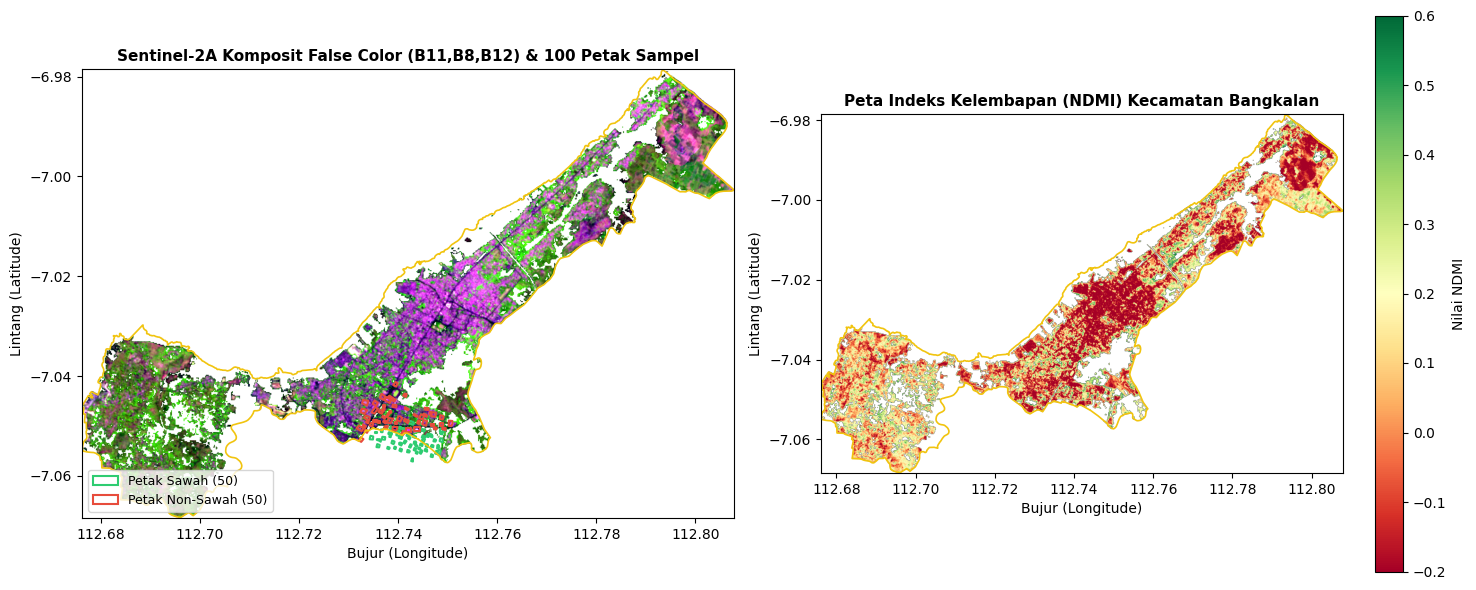

In [22]:
nd = lambda a, b: (a - b) / (a + b + 1e-10)
if USE_VIS:
    FEATURE_NAMES = ["band_blue", "band_green", "band_red", "band_nir", "band_swir1", "band_swir2", "ndvi", "ndwi", "ndmi"]
    feats = np.stack([B["B2"], B["B3"], B["B4"], B["B8"], B["B11"], B["B12"],
                      nd(B["B8"], B["B4"]), nd(B["B3"], B["B8"]), nd(B["B8"], B["B11"])]).astype("float32")
    used = ["B2", "B3", "B4", "B8", "B11", "B12"]
else:
    FEATURE_NAMES = ["band_nir", "band_swir1", "band_swir2", "ndmi", "nbr2"]
    feats = np.stack([B["B8"], B["B11"], B["B12"], nd(B["B8"], B["B11"]), nd(B["B11"], B["B12"])]).astype("float32")
    used = ["B8", "B11", "B12"]

valid = inside & np.isfinite(feats).all(axis=0) & np.all([B[n] > 0 for n in used], axis=0)
feats[:, ~valid] = np.nan
print(f"Piksel valid untuk analisis: {valid.sum():,} dari {inside.sum():,} piksel di dalam kecamatan "
      f"({valid.sum()/inside.sum():.1%})")

# ---------- visualisasi gaya contoh Sambeng (dipotong pas ke kecamatan) ----------
from rasterio.warp import transform as rio_transform
x0_, y0_, x1_, y1_ = aoi_proj.total_bounds
c0, c1 = max(int((x0_ - transform.c) / transform.a), 0), min(int(np.ceil((x1_ - transform.c) / transform.a)), W)
r0, r1 = max(int((transform.f - y1_) / -transform.e), 0), min(int(np.ceil((transform.f - y0_) / -transform.e)), H)
crop = (slice(r0, r1), slice(c0, c1))
lon, lat = rio_transform(crs, "EPSG:4326", [transform.c + c0 * transform.a, transform.c + c1 * transform.a],
                         [transform.f + r1 * transform.e, transform.f + r0 * transform.e])
ext_ll = [lon[0], lon[1], lat[0], lat[1]]          # [barat, timur, selatan, utara]
vc = valid[crop]

def stretch(a):
    lo, hi = np.nanpercentile(a[vc], [2, 98]); return np.clip((a - lo) / (hi - lo + 1e-10), 0, 1)
def komposit(b3):                                   # putih = di luar kecamatan / tanpa data
    img = np.dstack([stretch(B[n][crop]) for n in b3]); img[~vc] = 1.0; return img

BAND_TC   = ("B4", "B3", "B2") if USE_VIS else ("B11", "B8", "B12")   # Langkah 4
BAND_AGRI = ("B4", "B8", "B2") if USE_VIS else ("B11", "B8", "B12")   # Langkah 7 (komposit pertanian)
ttl = "Sentinel-2A True Color (RGB)" if USE_VIS else "Sentinel-2A Komposit False Color (B11,B8,B12)"
idx_img, idx_name = (feats[6], "NDVI") if USE_VIS else (feats[3], "NDMI")
n1, n0 = int((gdf_samples["class"] == 1).sum()), int((gdf_samples["class"] == 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(komposit(BAND_TC), extent=ext_ll)
gdf_samples[gdf_samples["class"] == 1].plot(ax=axes[0], facecolor="none", edgecolor="#2ecc71", linewidth=1.5)
gdf_samples[gdf_samples["class"] == 0].plot(ax=axes[0], facecolor="none", edgecolor="#e74c3c", linewidth=1.5)
gdf_aoi.boundary.plot(ax=axes[0], color="#f1c40f", linewidth=1.2)
axes[0].set_title(ttl + f" & {n1 + n0} Petak Sampel", fontsize=11, fontweight="bold")
axes[0].legend(handles=[mpatches.Patch(edgecolor="#2ecc71", facecolor="none", linewidth=1.5, label=f"Petak Sawah ({n1})"),
                        mpatches.Patch(edgecolor="#e74c3c", facecolor="none", linewidth=1.5, label=f"Petak Non-Sawah ({n0})")],
               loc="lower left", fontsize=9)
im = axes[1].imshow(np.where(vc, idx_img[crop], np.nan), cmap="RdYlGn", vmin=-0.2, vmax=0.9 if USE_VIS else 0.6, extent=ext_ll)
gdf_aoi.boundary.plot(ax=axes[1], color="#f1c40f", linewidth=1.2)
axes[1].set_title(f"Peta Indeks {'Kehijauan (NDVI)' if USE_VIS else 'Kelembapan (NDMI)'} Kecamatan Bangkalan", fontsize=11, fontweight="bold")
plt.colorbar(im, ax=axes[1], label=f"Nilai {idx_name}")
for a in axes:
    a.set_xlim(ext_ll[0], ext_ll[1]); a.set_ylim(ext_ll[2], ext_ll[3])
    a.set_xlabel("Bujur (Longitude)"); a.set_ylabel("Lintang (Latitude)")
plt.tight_layout(); plt.show()

---
## Langkah 5: Ekstraksi Nilai Spektral per Petak (`extract`)

Mengikuti tujuan fungsi `extract()` pada alur contoh, fitur spektral diekstrak dari piksel valid di dalam tiap poligon sampel (bukan hanya satu titik pusat). Bergantung pada kualitas band, fitur mencakup band Blue/Green/Red/NIR/SWIR serta indeks NDVI, NDWI, NDMI, atau NBR2. Setiap petak memiliki `id` unik dan menjadi satu grup untuk pembagian data latih/uji.

In [23]:
sp = gdf_samples.to_crs(crs)
poly_ras = features.rasterize([(g, int(i)) for g, i in zip(sp.geometry, sp["id"])], out_shape=(H, W),
                              transform=transform, fill=0, dtype="int32")
lab_mask = (poly_ras > 0) & valid
X = feats[:, lab_mask].T
groups = poly_ras[lab_mask]
cls_of = dict(zip(gdf_samples["id"], gdf_samples["class"]))
lab_lut = np.zeros(int(poly_ras.max()) + 1, dtype="uint8")
for i, k in cls_of.items(): lab_lut[i] = k
y = lab_lut[groups]
present = np.unique(groups)

df_features = pd.DataFrame(X, columns=FEATURE_NAMES)
df_features["id"], df_features["class"] = groups, y
df_features["label"] = np.where(y == 1, "Sawah", "Bukan Sawah")

print(f"Petak terpakai: {len(present)} dari {len(gdf_samples)} | piksel: {len(y)}")
print(df_features.groupby("label").agg(petak=("id", "nunique"), piksel=("id", "size")).to_string())
if len(present) < len(gdf_samples):
    print("PERINGATAN: sebagian petak tidak punya piksel valid (di luar citra / tanpa data).")
print("\nRata-rata respon spektral per kelas:")
print(df_features.groupby("label")[FEATURE_NAMES].mean().round(3).T)

Petak terpakai: 64 dari 100 | piksel: 2871
             petak  piksel
label                     
Bukan Sawah     50    2640
Sawah           14     231
PERINGATAN: sebagian petak tidak punya piksel valid (di luar citra / tanpa data).

Rata-rata respon spektral per kelas:
label       Bukan Sawah  Sawah
band_nir          0.119  0.181
band_swir1        0.168  0.111
band_swir2        0.136  0.024
ndmi             -0.180  0.236
nbr2              0.140  0.705


---
## Langkah 6: Pelatihan & Evaluasi Random Forest

Model Random Forest menggunakan fitur spektral hasil ekstraksi. Evaluasi mengikuti pembagian **80% latih / 20% uji per petak**; seluruh piksel dari petak yang sama hanya masuk ke salah satu bagian, sehingga mengurangi kebocoran data spasial.

Hasil evaluasi mencakup **Overall Accuracy**, **Cohen's Kappa**, **Confusion Matrix**, laporan presisi/recall/F1, dan **Feature Importance**. `class_weight="balanced"` membantu menangani jumlah piksel yang tidak seimbang. Validasi silang per petak memberi gambaran tambahan selain satu pembagian latih/uji.

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, classification_report

rng = np.random.default_rng(SEED)
test_ids = []
for k in (0, 1):
    ids = [p for p in present if cls_of[p] == k]; rng.shuffle(ids)
    test_ids += ids[:max(1, int(round(len(ids) * TEST_SIZE)))]
m_te = np.isin(groups, test_ids)
X_tr, y_tr, X_te, y_te = X[~m_te], y[~m_te], X[m_te], y[m_te]
print(f"Petak latih: {len(present)-len(test_ids)} | uji: {len(test_ids)}  ||  piksel latih: {len(y_tr)} | uji: {len(y_te)}")

rf_model = RandomForestClassifier(n_estimators=N_TREES, class_weight="balanced", random_state=SEED, n_jobs=-1).fit(X_tr, y_tr)
y_pred = rf_model.predict(X_te)

cm = confusion_matrix(y_te, y_pred, labels=[0, 1])
df_conf = pd.DataFrame(cm, index=["Aktual: Non-Sawah", "Aktual: Sawah"], columns=["Prediksi: Non-Sawah", "Prediksi: Sawah"])
print("=" * 60, "\nHASIL EVALUASI RANDOM FOREST (SAWAH vs NON-SAWAH)\n" + "=" * 60)
print(f"Overall Accuracy : {accuracy_score(y_te, y_pred)*100:.2f}%")
print(f"Kappa Index      : {cohen_kappa_score(y_te, y_pred):.4f}\n")
print(df_conf, "\n")
print(classification_report(y_te, y_pred, labels=[0, 1], target_names=["Non-Sawah", "Sawah"], zero_division=0))
df_conf.to_csv(OUT / "confusion_matrix_sawah.csv", sep=";")

oa, kp = [], []
for tr, te in GroupKFold(n_splits=min(5, len(present))).split(X, y, groups):
    m = RandomForestClassifier(n_estimators=N_TREES, class_weight="balanced", random_state=SEED, n_jobs=-1).fit(X[tr], y[tr])
    p = m.predict(X[te]); oa.append(accuracy_score(y[te], p)); kp.append(cohen_kappa_score(y[te], p))
print(f"Validasi silang per petak: OA = {np.mean(oa)*100:.1f}% ± {np.std(oa)*100:.1f} | Kappa = {np.mean(kp):.3f} ± {np.std(kp):.3f}")

print("\nTingkat Kepentingan Fitur:")
print(pd.DataFrame({"Fitur": FEATURE_NAMES, "Tingkat Kepentingan": rf_model.feature_importances_})
      .sort_values("Tingkat Kepentingan", ascending=False).round(4).to_string(index=False))

Petak latih: 51 | uji: 13  ||  piksel latih: 2325 | uji: 546
HASIL EVALUASI RANDOM FOREST (SAWAH vs NON-SAWAH)
Overall Accuracy : 96.52%
Kappa Index      : 0.7767

                   Prediksi: Non-Sawah  Prediksi: Sawah
Aktual: Non-Sawah                  490                9
Aktual: Sawah                       10               37 

              precision    recall  f1-score   support

   Non-Sawah       0.98      0.98      0.98       499
       Sawah       0.80      0.79      0.80        47

    accuracy                           0.97       546
   macro avg       0.89      0.88      0.89       546
weighted avg       0.96      0.97      0.97       546

Validasi silang per petak: OA = 96.5% ± 2.3 | Kappa = 0.675 ± 0.180

Tingkat Kepentingan Fitur:
     Fitur  Tingkat Kepentingan
      nbr2               0.4236
band_swir2               0.2457
      ndmi               0.2063
band_swir1               0.0736
  band_nir               0.0508


---
## Langkah 7: Klasifikasi Seluruh Kecamatan & Peta Berdampingan

Model akhir dilatih ulang dengan **seluruh** data petak, lalu diterapkan bertahap ke piksel valid di dalam Kecamatan Bangkalan. Hasil disimpan sebagai `hasil_bangkalan/klasifikasi_sawah_bangkalan.tif` untuk dibuka di QGIS; nilai **255** menandai area di luar AOI atau piksel tanpa data. Peta hasil ditampilkan berdampingan dengan komposit citra, dan luas kelas dihitung dari ukuran piksel GeoTIFF.

GeoTIFF: /content/hasil_bangkalan/klasifikasi_sawah_bangkalan.tif
Sawah     : 64,713 piksel = 647.1 ha (24.5%)
Non-Sawah : 199,792 piksel = 1,997.9 ha (75.5%)
Tanpa data di dalam kecamatan: 964.1 ha


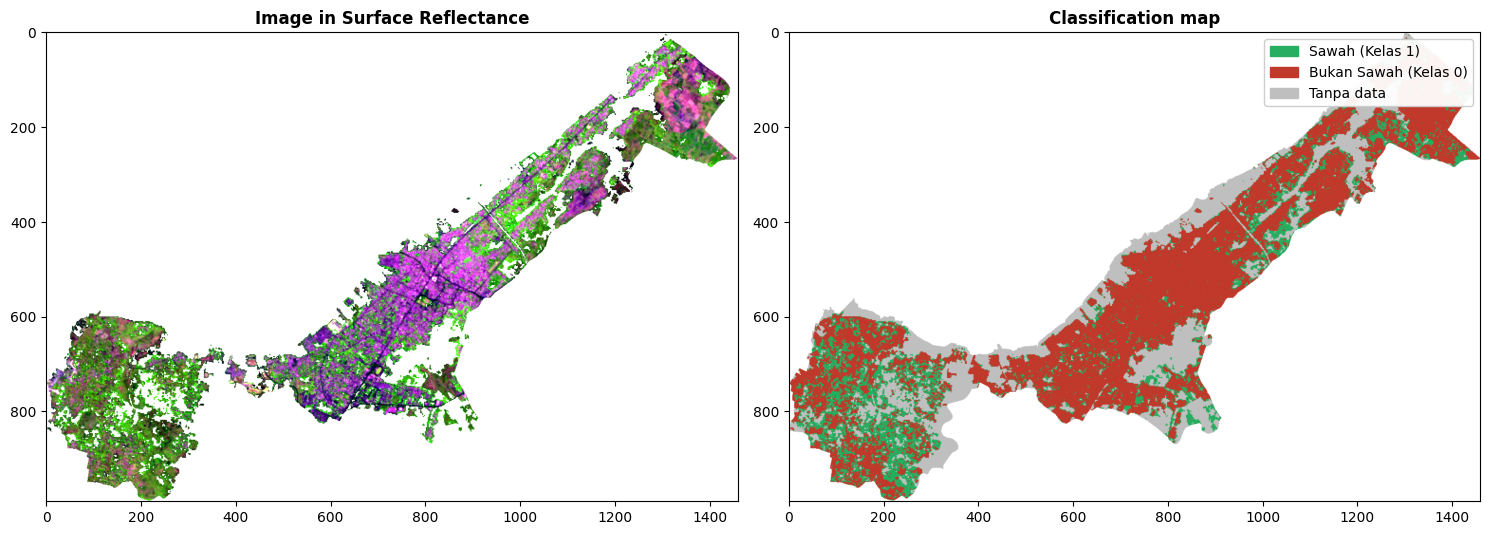

In [25]:
rf_final = RandomForestClassifier(n_estimators=N_TREES, class_weight="balanced", random_state=SEED, n_jobs=-1).fit(X, y)

nf = feats.shape[0]; flat = feats.reshape(nf, -1)
idx = np.flatnonzero(valid.ravel())
pred = np.full(H * W, 255, dtype="uint8")
for s in range(0, len(idx), 1_000_000):
    j = idx[s:s + 1_000_000]
    pred[j] = rf_final.predict(flat[:, j].T).astype("uint8")
classification_map = pred.reshape(H, W)

out_tif = OUT / "klasifikasi_sawah_bangkalan.tif"
prof.update(driver="GTiff", dtype="uint8", count=1, nodata=255, compress="lzw")
with rasterio.open(out_tif, "w", **prof) as dst:
    dst.write(classification_map, 1)
    dst.set_band_description(1, "kelas (1=sawah, 0=non-sawah)")
    dst.write_colormap(1, {0: (215, 25, 28, 255), 1: (26, 150, 65, 255), 255: (0, 0, 0, 0)})
print("GeoTIFF:", out_tif)

n_s, n_n = int((classification_map == 1).sum()), int((classification_map == 0).sum())
ha = abs(transform.a * transform.e) / 10000
print(f"Sawah     : {n_s:,} piksel = {n_s*ha:,.1f} ha ({n_s/(n_s+n_n):.1%})")
print(f"Non-Sawah : {n_n:,} piksel = {n_n*ha:,.1f} ha ({n_n/(n_s+n_n):.1%})")
print(f"Tanpa data di dalam kecamatan: {(inside & ~valid).sum()*ha:,.1f} ha")

# ---------- peta berdampingan gaya contoh Sambeng ----------
from matplotlib.colors import to_rgb
cm_c = classification_map[crop]
kelas_rgb = np.ones(cm_c.shape + (3,))                    # putih = di luar kecamatan
kelas_rgb[inside[crop] & ~vc] = (0.75, 0.75, 0.75)         # abu-abu = di dalam kecamatan tapi tanpa data
kelas_rgb[cm_c == 1] = to_rgb("#27ae60")
kelas_rgb[cm_c == 0] = to_rgb("#c0392b")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(komposit(BAND_AGRI))
axes[0].set_title("Image in Surface Reflectance", fontsize=12, fontweight="bold"); axes[0].grid(False)
axes[1].imshow(kelas_rgb)
axes[1].set_title("Classification map", fontsize=12, fontweight="bold"); axes[1].grid(False)
axes[1].legend(handles=[mpatches.Patch(color="#27ae60", label="Sawah (Kelas 1)"),
                        mpatches.Patch(color="#c0392b", label="Bukan Sawah (Kelas 0)"),
                        mpatches.Patch(color="#bfbfbf", label="Tanpa data")], loc="upper right", framealpha=0.95)
plt.tight_layout(); plt.savefig(OUT / "peta_klasifikasi_bangkalan.png", dpi=150); plt.show()

---
## Langkah 8: Peta Interaktif (Google Satellite, Esri, OpenStreetMap)

Peta Folium menampilkan batas Kecamatan Bangkalan dan poligon sampel dengan popup kelas, tipe, serta koordinat. Gunakan kontrol lapisan untuk membandingkan Google Satellite Hybrid, Google Satellite, Esri World Imagery, dan OpenStreetMap. Berkas HTML mandiri disimpan di `hasil_bangkalan/peta_sampel_bangkalan.html`.

In [26]:
import folium
m = folium.Map(location=[(miny + maxy) / 2, (minx + maxx) / 2], zoom_start=13, tiles=None)
for nm_, url, att in [("Google Satellite (Hybrid)", "https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}", "Google"),
                      ("Google Satellite", "https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}", "Google"),
                      ("Esri World Imagery", "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}", "Esri")]:
    folium.TileLayer(tiles=url, attr=att, name=nm_, overlay=False).add_to(m)
folium.TileLayer("OpenStreetMap", name="OpenStreetMap", overlay=False).add_to(m)
folium.GeoJson(gdf_aoi.to_json(), name="Batas Kecamatan Bangkalan",
               style_function=lambda x: {"fillColor": "none", "color": "#f1c40f", "weight": 3, "dashArray": "6,6"}).add_to(m)
for k, nm_, col in ((1, "Sawah", "#27ae60"), (0, "Bukan Sawah", "#c0392b")):
    fg = folium.FeatureGroup(name=f"{nm_} ({(gdf_samples['class'] == k).sum()})")
    for _, r in gdf_samples[gdf_samples["class"] == k].iterrows():
        folium.GeoJson(r.geometry, style_function=lambda x, c=col: {"color": c, "fillColor": c, "weight": 2, "fillOpacity": .6},
                       popup=folium.Popup(f"<b>ID:</b> {r['id']}<br><b>Kelas:</b> {nm_}<br><b>Tipe:</b> {r['tipe']}<br>{r['lat']:.5f}, {r['lon']:.5f}", max_width=250),
                       tooltip=f"#{r['id']} {nm_}").add_to(fg)
    fg.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
m.save(OUT / "peta_sampel_bangkalan.html")
print("Peta interaktif:", OUT / "peta_sampel_bangkalan.html")
m

Peta interaktif: /content/hasil_bangkalan/peta_sampel_bangkalan.html


---
## Langkah 9: Kesimpulan & Panduan Buka di QGIS

**Keluaran** (folder `hasil_bangkalan/`): `klasifikasi_sawah_bangkalan.tif`, `sampel_sawah_bangkalan.zip` (+ `.qml`), `sampel_sawah_bangkalan.geojson`, `peta_klasifikasi_bangkalan.png`, `peta_sampel_bangkalan.html`, dan `confusion_matrix_sawah.csv`.

### Membuka hasil di QGIS
1. Ekstrak `sampel_sawah_bangkalan.zip`, lalu tambahkan `sampel_sawah_bangkalan.shp`. Berkas `.qml` di dalam paket mengatur warna kelas secara otomatis.
2. Tambahkan basemap melalui **Browser → XYZ Tiles → New Connection**, gunakan URL `https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}`, lalu letakkan basemap di bawah layer sampel.
3. Tambahkan `klasifikasi_sawah_bangkalan.tif`: kelas 0 adalah bukan sawah (merah), kelas 1 adalah sawah (hijau), dan 255 adalah tanpa data.

### Catatan interpretasi
- Kualitas peta dan metrik evaluasi bergantung pada ketepatan label serta sebaran sampel. Pastikan kelas bukan sawah mencakup tegalan, kebun, lahan bera, dan tambak.
- Jika band B2/B3/B4 bermasalah, hasil menggunakan fitur SWIR/NIR saja. Periksa kembali ekspor citra dari GEE, terutama proses scaling/offset.
- Citra satu tanggal tidak menangkap seluruh fase tanam; komposit median multi-tanggal dapat memberi gambaran sawah yang lebih stabil.